In [18]:
#import statements

import numpy as np
import matplotlib.pyplot as plt

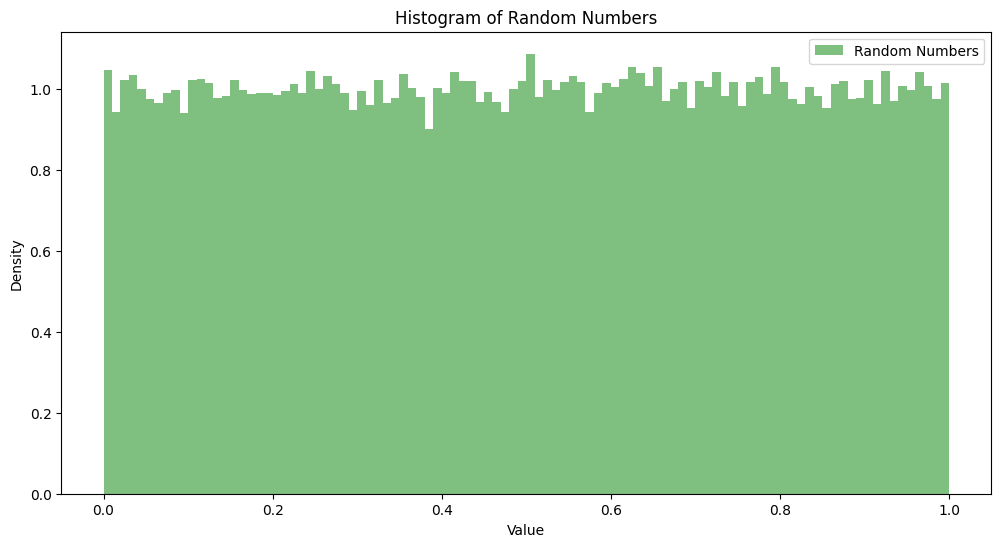

In [19]:
#random generator object; seed 42 for reproducibility
rng = np.random.default_rng(seed = 42)

#generate 100,000 random numbers between 0 and 1
rand_array = rng.random(100000)

#plotting the results of the random number generation
fig, ax = plt.subplots(figsize=(12,6))

ax.hist(rand_array, bins = 100, density = True, alpha = 0.5, color = 'green', label = 'Random Numbers')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.set_title('Histogram of Random Numbers')
ax.legend()
plt.show()


In [20]:
#method defining how to plot the histogram of the sum for different 
#sample numbers M from the random number array.
def hist_plots__1(M):
    X = []
    for i in range(100000):
        sum = 0
        #M random numbers generated in range 0 to 1, then scaled to match indexing of rand_array
        #Then truncated just to get the integer index value to extract from rand_array
        rand_index = np.trunc(rng.random(M)*len(rand_array))
        #Finding the sum of retrieved elements
        for i in range(M):
            sum += rand_array[int(rand_index[i])]
        X.append(sum)
    
    return X, M

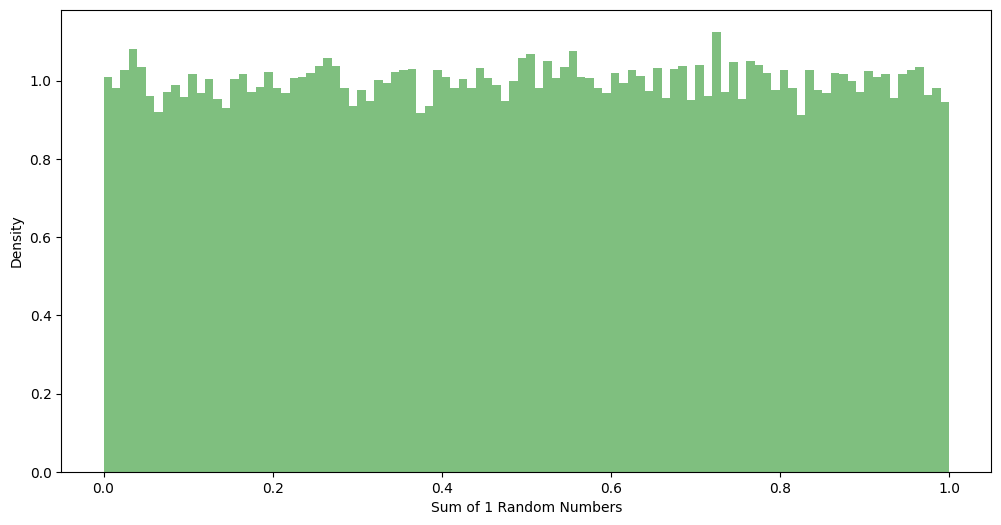

In [21]:
#plotting for M = 1
figure, ax = plt.subplots(figsize=(12,6))
X_1, M_1 = hist_plots__1(1)
ax.hist(X_1, bins = 100*M_1, density = True, alpha = 0.5, color = 'green')
ax.set_xlabel(f'Sum of {M_1} Random Numbers')
ax.set_ylabel('Density')
plt.show()

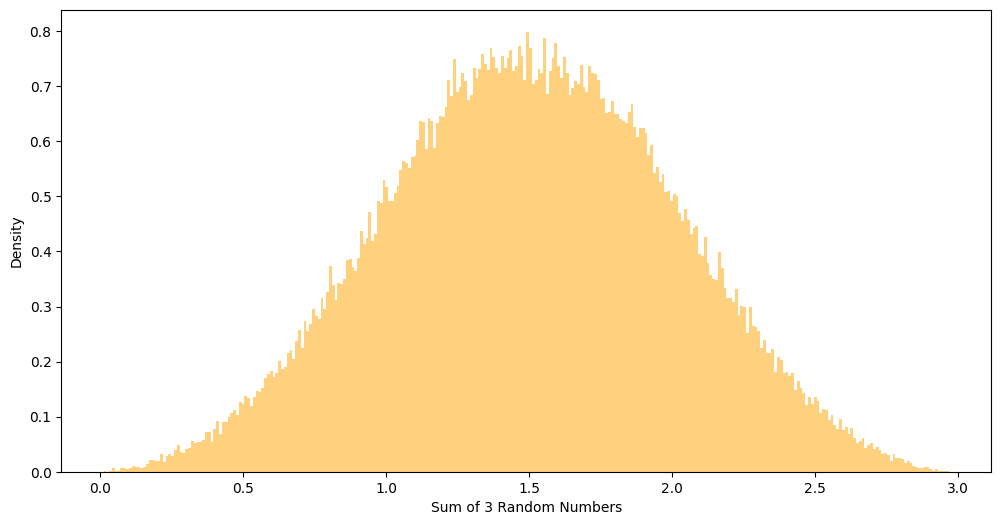

In [22]:
#plotting for M = 3
figure, ax = plt.subplots(figsize=(12,6))
X_3, M_3 = hist_plots__1(3)
ax.hist(X_3, bins = 100*M_3, density = True, alpha = 0.5, color = 'orange')
ax.set_xlabel(f'Sum of {M_3} Random Numbers')
ax.set_ylabel('Density')
plt.show()

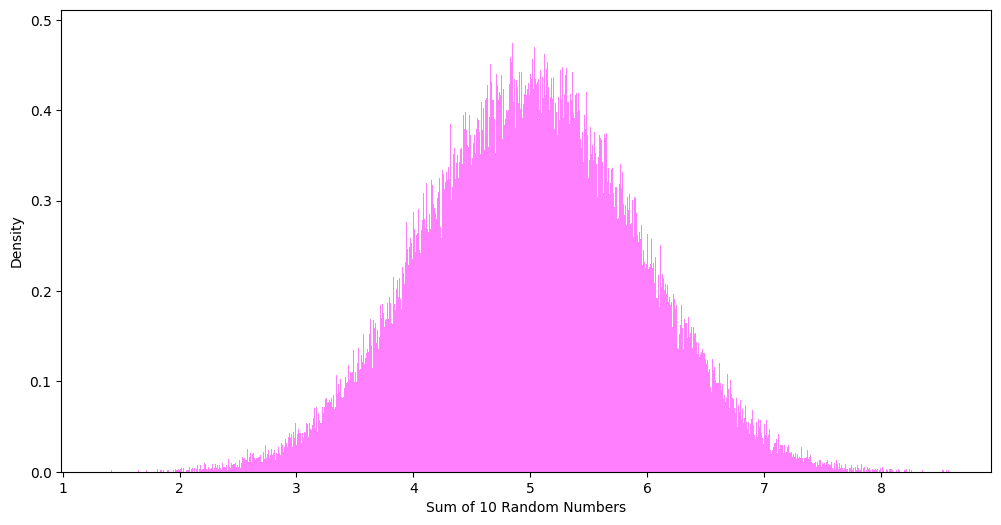

In [23]:
#plotting for M = 10
figure, ax = plt.subplots(figsize=(12,6))
X_10, M_10 = hist_plots__1(10)
ax.hist(X_10, bins = 100*M_10, density = True, alpha = 0.5, color = 'magenta')
ax.set_xlabel(f'Sum of {M_10} Random Numbers')
ax.set_ylabel('Density')
plt.show()

The idea of the central limit theorem is that if you were to draw from the same distribution many independent random variables, the distribution of the resulting sum approaches a normal distribution. This is what is observed in the above plots, as you increase the number of variables accounting for each element in the array. When $M=1$, you see simply a similar distribution as the initial random distrbituion. But taking $M=3$ takes three random elements and sums them, and logically it makes sense that on average the sum should be $1.5(0.5 \cdot 3)$, which is what the distribution shows. That happens a majority of the time, which is shown by the peak of the distribution located here. There is then less instances of other sums moving outwards from the center(less ways to accumulate those sums in comparison to 1.5), which is why it tapers off at ends; this is the normal distribution. Increasing M shows the distribution, shifted to be centered at $(M \cdot 0.5)$. As long as we sample enough, we will always see this distribtuion shape as we increase M.

Mean values; M = 1: 0.5008, 3: 1.5043, 10: 5.0053
Standard deviations;  M = 1: 0.288, 3: 0.4991, 10: 0.914


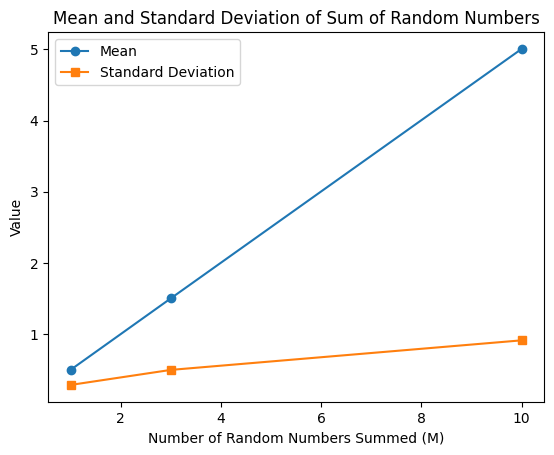

In [24]:
#plotting mean and std found for each value of M value. 
# In future, mean and std can maybe be more easily found using in-built numpy methods

M_values = [1, 3, 10]
X_values = [X_1, X_3, X_10]
def my_mean(array):
    return sum(array)/len(array)

def std_dev(array):
    array_squared = [x**2 for x in array]
    mean_array_squared = my_mean(array_squared)
    mean_squared = my_mean(array)**2
    return (mean_array_squared - mean_squared)**0.5

X_mean = [my_mean(i) for i in X_values]
X_std_dev = [std_dev(i) for i in X_values]

print(f"Mean values; M = 1: {np.round(X_mean[0], decimals = 4)}, 3: {np.round(X_mean[1], decimals = 4)}, 10: {np.round(X_mean[2], decimals = 4)}")
print(f"Standard deviations;  M = 1: {np.round(X_std_dev[0], decimals = 4)}, 3: {np.round(X_std_dev[1], decimals = 4)}, 10: {np.round(X_std_dev[2], decimals = 4)}")

plt.plot(M_values, X_mean, marker='o', label='Mean')
plt.plot(M_values, X_std_dev, marker='s', label='Standard Deviation')
plt.legend()
plt.xlabel('Number of Random Numbers Summed (M)')
plt.ylabel('Value')
plt.title('Mean and Standard Deviation of Sum of Random Numbers')
plt.show()

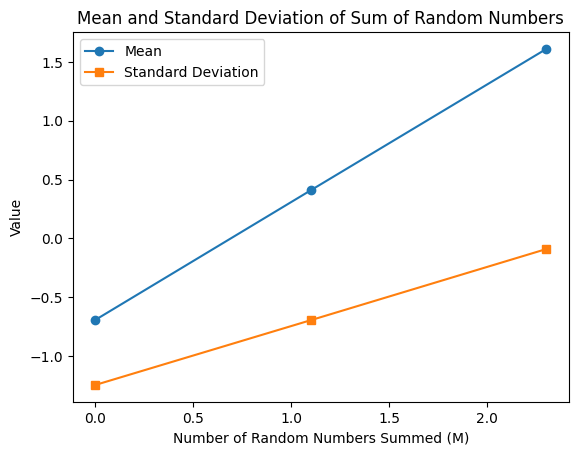

In [25]:
#Creating Log-log plot for the graphs using np.log

plt.plot(np.log(M_values), np.log(X_mean), marker='o', label='Mean')
plt.plot(np.log(M_values), np.log(X_std_dev), marker='s', label='Standard Deviation')
plt.legend()
plt.xlabel('Number of Random Numbers Summed (M)')
plt.ylabel('Value')
plt.title('Mean and Standard Deviation of Sum of Random Numbers')
plt.show()